In [1]:
import time

In [2]:
start = time.time()

In [3]:
!pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [4]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=e466319e001cb86b7814ebc900eabde65b37f14c687aa57f18da1d9a0071583f
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget


In [5]:
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import pandas as pd
import numpy as np
np.random.seed(0)

import scipy

import os
import wget
from pathlib import Path

from matplotlib import pyplot as plt
%matplotlib inline

In [6]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = f"1"

In [7]:
import torch
torch.__version__

'2.6.0+cu124'

# Download census-income dataset

In [8]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
dataset_name = 'census-income'
out = Path(os.getcwd()+'/data/'+dataset_name+'.csv')

In [9]:
out.parent.mkdir(parents=True, exist_ok=True)
if out.exists():
    print("File already exists.")
else:
    print("Downloading file...")
    wget.download(url, out.as_posix())

# Load data and split

In [10]:
train = pd.read_csv(out)
target = ' <=50K'
if "Set" not in train.columns:
    train["Set"] = np.random.choice(["train", "valid", "test"], p =[.8, .1, .1], size=(train.shape[0],))

train_indices = train[train.Set=="train"].index
valid_indices = train[train.Set=="valid"].index
test_indices = train[train.Set=="test"].index

# Simple preprocessing

Label encode categorical features and fill empty cells.

In [11]:
nunique = train.nunique()
types = train.dtypes

categorical_columns = []
categorical_dims =  {}
for col in train.columns:
    if types[col] == 'object' or nunique[col] < 200:
        print(col, train[col].nunique())
        l_enc = LabelEncoder()
        train[col] = train[col].fillna("VV_likely")
        train[col] = l_enc.fit_transform(train[col].values)
        categorical_columns.append(col)
        categorical_dims[col] = len(l_enc.classes_)
    else:
        train.fillna(train.loc[train_indices, col].mean(), inplace=True)

39 73
 State-gov 9
 Bachelors 16
 13 16
 Never-married 7
 Adm-clerical 15
 Not-in-family 6
 White 5
 Male 2
 2174 119
 0 92
 40 94
 United-States 42
 <=50K 2
Set 3


In [12]:
# check that pipeline accepts strings
train.loc[train[target]==0, target] = "wealthy"
train.loc[train[target]==1, target] = "not_wealthy"

<ipython-input-12-b107fcde6490>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'wealthy' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[train[target]==0, target] = "wealthy"


# Define categorical features for categorical embeddings

In [13]:
unused_feat = ['Set']

features = [ col for col in train.columns if col not in unused_feat+[target]]

cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]

cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]


# Grouped features

You can now specify groups of feature which will share a common attention.

This may be very usefull for features comming from a same preprocessing technique like PCA for example.

In [14]:
len(features)

14

In [15]:
grouped_features = [[0, 1, 2], [8, 9, 10]]

# Network parameters

In [16]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 "grouped_features" : grouped_features
                }

clf = TabNetClassifier(**tabnet_params
                      )

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


# Training

In [17]:
X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

In [18]:
max_epochs = 50 if not os.getenv("CI", False) else 2

In [19]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

In [20]:
# This illustrates the behaviour of the model's fit method using Compressed Sparse Row matrices
sparse_X_train = scipy.sparse.csr_matrix(X_train)  # Create a CSR matrix from X_train
sparse_X_valid = scipy.sparse.csr_matrix(X_valid)  # Create a CSR matrix from X_valid

# Fitting the model
clf.fit(
    X_train=sparse_X_train, y_train=y_train,
    eval_set=[(sparse_X_train, y_train), (sparse_X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=max_epochs , patience=20,
    batch_size=1024, virtual_batch_size=128,
    num_workers=0,
    weights=1,
    drop_last=False,
    augmentations=aug, #aug, None
)

epoch 0  | loss: 0.58039 | train_auc: 0.81603 | valid_auc: 0.82541 |  0:00:07s
epoch 1  | loss: 0.47431 | train_auc: 0.86123 | valid_auc: 0.86594 |  0:00:12s
epoch 2  | loss: 0.45242 | train_auc: 0.88246 | valid_auc: 0.88437 |  0:00:18s
epoch 3  | loss: 0.43115 | train_auc: 0.89496 | valid_auc: 0.8941  |  0:00:24s
epoch 4  | loss: 0.42419 | train_auc: 0.90402 | valid_auc: 0.9033  |  0:00:29s
epoch 5  | loss: 0.41078 | train_auc: 0.90977 | valid_auc: 0.91151 |  0:00:34s
epoch 6  | loss: 0.39628 | train_auc: 0.91397 | valid_auc: 0.91681 |  0:00:39s
epoch 7  | loss: 0.39185 | train_auc: 0.91789 | valid_auc: 0.9221  |  0:00:45s
epoch 8  | loss: 0.3884  | train_auc: 0.92078 | valid_auc: 0.92504 |  0:00:50s
epoch 9  | loss: 0.38239 | train_auc: 0.92131 | valid_auc: 0.92382 |  0:00:55s
epoch 10 | loss: 0.37835 | train_auc: 0.92278 | valid_auc: 0.92278 |  0:01:01s
epoch 11 | loss: 0.37798 | train_auc: 0.926   | valid_auc: 0.92547 |  0:01:06s
epoch 12 | loss: 0.37593 | train_auc: 0.92697 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [21]:
# This illustrates the warm_start=False behaviour
save_history = []

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['auc'],
        max_epochs=max_epochs , patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=False
    )
    save_history.append(clf.history["valid_auc"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

save_history = []  # Resetting the list to show that it also works when computing feature importance

# Fitting the model without starting from a warm start but with the computing of the feature importance activated
for _ in range(2):
    clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['auc'],
        max_epochs=max_epochs , patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True # True by default so not needed
    )
    save_history.append(clf.history["valid_auc"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

epoch 0  | loss: 0.58039 | train_auc: 0.81603 | valid_auc: 0.82541 |  0:00:02s
epoch 1  | loss: 0.47431 | train_auc: 0.86123 | valid_auc: 0.86594 |  0:00:03s
epoch 2  | loss: 0.45242 | train_auc: 0.88246 | valid_auc: 0.88437 |  0:00:05s
epoch 3  | loss: 0.43115 | train_auc: 0.89496 | valid_auc: 0.8941  |  0:00:07s
epoch 4  | loss: 0.42419 | train_auc: 0.90402 | valid_auc: 0.9033  |  0:00:09s
epoch 5  | loss: 0.41078 | train_auc: 0.90977 | valid_auc: 0.91151 |  0:00:11s
epoch 6  | loss: 0.39628 | train_auc: 0.91397 | valid_auc: 0.91681 |  0:00:13s
epoch 7  | loss: 0.39185 | train_auc: 0.91789 | valid_auc: 0.9221  |  0:00:15s
epoch 8  | loss: 0.3884  | train_auc: 0.92078 | valid_auc: 0.92504 |  0:00:17s
epoch 9  | loss: 0.38239 | train_auc: 0.92131 | valid_auc: 0.92382 |  0:00:18s
epoch 10 | loss: 0.37835 | train_auc: 0.92278 | valid_auc: 0.92278 |  0:00:20s
epoch 11 | loss: 0.37798 | train_auc: 0.926   | valid_auc: 0.92547 |  0:00:22s
epoch 12 | loss: 0.37593 | train_auc: 0.92697 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.58039 | train_auc: 0.81603 | valid_auc: 0.82541 |  0:00:01s
epoch 1  | loss: 0.47431 | train_auc: 0.86123 | valid_auc: 0.86594 |  0:00:04s
epoch 2  | loss: 0.45242 | train_auc: 0.88246 | valid_auc: 0.88437 |  0:00:06s
epoch 3  | loss: 0.43115 | train_auc: 0.89496 | valid_auc: 0.8941  |  0:00:07s
epoch 4  | loss: 0.42419 | train_auc: 0.90402 | valid_auc: 0.9033  |  0:00:09s
epoch 5  | loss: 0.41078 | train_auc: 0.90977 | valid_auc: 0.91151 |  0:00:11s
epoch 6  | loss: 0.39628 | train_auc: 0.91397 | valid_auc: 0.91681 |  0:00:13s
epoch 7  | loss: 0.39185 | train_auc: 0.91789 | valid_auc: 0.9221  |  0:00:15s
epoch 8  | loss: 0.3884  | train_auc: 0.92078 | valid_auc: 0.92504 |  0:00:17s
epoch 9  | loss: 0.38239 | train_auc: 0.92131 | valid_auc: 0.92382 |  0:00:19s
epoch 10 | loss: 0.37835 | train_auc: 0.92278 | valid_auc: 0.92278 |  0:00:21s
epoch 11 | loss: 0.37798 | train_auc: 0.926   | valid_auc: 0.92547 |  0:00:22s
epoch 12 | loss: 0.37593 | train_auc: 0.92697 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.58039 | train_auc: 0.81603 | valid_auc: 0.82541 |  0:00:01s
epoch 1  | loss: 0.47431 | train_auc: 0.86123 | valid_auc: 0.86594 |  0:00:03s
epoch 2  | loss: 0.45242 | train_auc: 0.88246 | valid_auc: 0.88437 |  0:00:05s
epoch 3  | loss: 0.43115 | train_auc: 0.89496 | valid_auc: 0.8941  |  0:00:07s
epoch 4  | loss: 0.42419 | train_auc: 0.90402 | valid_auc: 0.9033  |  0:00:09s
epoch 5  | loss: 0.41078 | train_auc: 0.90977 | valid_auc: 0.91151 |  0:00:11s
epoch 6  | loss: 0.39628 | train_auc: 0.91397 | valid_auc: 0.91681 |  0:00:13s
epoch 7  | loss: 0.39185 | train_auc: 0.91789 | valid_auc: 0.9221  |  0:00:15s
epoch 8  | loss: 0.3884  | train_auc: 0.92078 | valid_auc: 0.92504 |  0:00:16s
epoch 9  | loss: 0.38239 | train_auc: 0.92131 | valid_auc: 0.92382 |  0:00:18s
epoch 10 | loss: 0.37835 | train_auc: 0.92278 | valid_auc: 0.92278 |  0:00:20s
epoch 11 | loss: 0.37798 | train_auc: 0.926   | valid_auc: 0.92547 |  0:00:22s
epoch 12 | loss: 0.37593 | train_auc: 0.92697 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.58039 | train_auc: 0.81603 | valid_auc: 0.82541 |  0:00:02s
epoch 1  | loss: 0.47431 | train_auc: 0.86123 | valid_auc: 0.86594 |  0:00:03s
epoch 2  | loss: 0.45242 | train_auc: 0.88246 | valid_auc: 0.88437 |  0:00:05s
epoch 3  | loss: 0.43115 | train_auc: 0.89496 | valid_auc: 0.8941  |  0:00:07s
epoch 4  | loss: 0.42419 | train_auc: 0.90402 | valid_auc: 0.9033  |  0:00:09s
epoch 5  | loss: 0.41078 | train_auc: 0.90977 | valid_auc: 0.91151 |  0:00:10s
epoch 6  | loss: 0.39628 | train_auc: 0.91397 | valid_auc: 0.91681 |  0:00:13s
epoch 7  | loss: 0.39185 | train_auc: 0.91789 | valid_auc: 0.9221  |  0:00:15s
epoch 8  | loss: 0.3884  | train_auc: 0.92078 | valid_auc: 0.92504 |  0:00:17s
epoch 9  | loss: 0.38239 | train_auc: 0.92131 | valid_auc: 0.92382 |  0:00:18s
epoch 10 | loss: 0.37835 | train_auc: 0.92278 | valid_auc: 0.92278 |  0:00:20s
epoch 11 | loss: 0.37798 | train_auc: 0.926   | valid_auc: 0.92547 |  0:00:22s
epoch 12 | loss: 0.37593 | train_auc: 0.92697 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


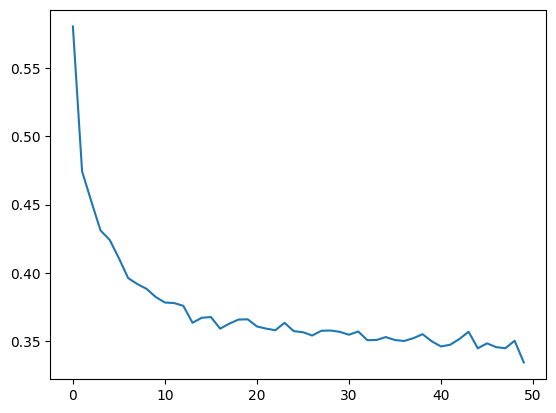

In [22]:
# plot losses
plt.plot(clf.history['loss'])

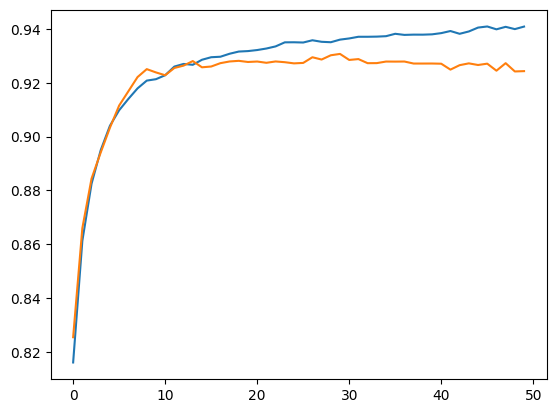

In [23]:
# plot auc
plt.plot(clf.history['train_auc'])
plt.plot(clf.history['valid_auc'])

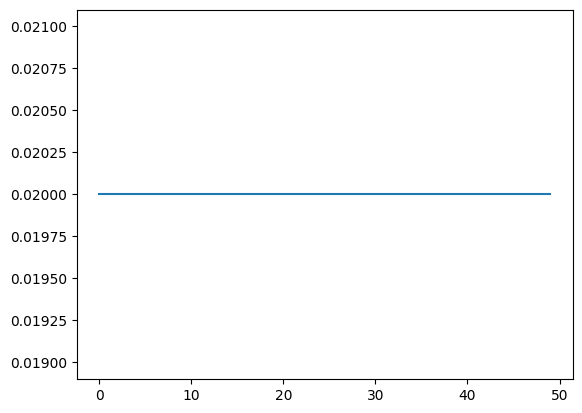

In [24]:
# plot learning rates
plt.plot(clf.history['lr'])

## Predictions

In [25]:
preds = clf.predict_proba(X_test)
test_auc = roc_auc_score(y_score=preds[:,1], y_true=y_test)


preds_valid = clf.predict_proba(X_valid)
valid_auc = roc_auc_score(y_score=preds_valid[:,1], y_true=y_valid)

print(f"BEST VALID SCORE FOR {dataset_name} : {clf.best_cost}")
print(f"FINAL TEST SCORE FOR {dataset_name} : {test_auc}")

BEST VALID SCORE FOR census-income : 0.9306975262472645
FINAL TEST SCORE FOR census-income : 0.92624806447162


In [26]:
# check that best weights are used
assert np.isclose(valid_auc, np.max(clf.history['valid_auc']), atol=1e-6)

In [27]:
clf.predict(X_test)

array(['not_wealthy', 'not_wealthy', 'wealthy', ..., 'not_wealthy',
       'wealthy', 'wealthy'], dtype='<U11')

# Save and load Model

In [28]:
# save tabnet model
saving_path_name = "./tabnet_model_test_1"
saved_filepath = clf.save_model(saving_path_name)

Successfully saved model at ./tabnet_model_test_1.zip


In [29]:
# define new model with basic parameters and load state dict weights
loaded_clf = TabNetClassifier()
loaded_clf.load_model(saved_filepath)

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [30]:
loaded_preds = loaded_clf.predict_proba(X_test)
loaded_test_auc = roc_auc_score(y_score=loaded_preds[:,1], y_true=y_test)

print(f"FINAL TEST SCORE FOR {dataset_name} : {loaded_test_auc}")

FINAL TEST SCORE FOR census-income : 0.92624806447162


In [31]:
assert(test_auc == loaded_test_auc)

In [32]:
loaded_clf.predict(X_test)

array(['not_wealthy', 'not_wealthy', 'wealthy', ..., 'not_wealthy',
       'wealthy', 'wealthy'], dtype='<U11')

# Global explainability : feat importance summing to 1

In [33]:
clf.feature_importances_

array([0.03504346, 0.03504346, 0.03504346, 0.03070843, 0.11777927,
       0.32325356, 0.13830008, 0.02580644, 0.05287576, 0.05287576,
       0.05287576, 0.04380496, 0.05150199, 0.0050876 ])

# Local explainability and masks

In [34]:
explain_matrix, masks = clf.explain(X_test)

<ipython-input-35-cdd8a56390e0>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(labels = features, rotation=45)
<ipython-input-35-cdd8a56390e0>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(labels = features, rotation=45)
<ipython-input-35-cdd8a56390e0>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(labels = features, rotation=45)


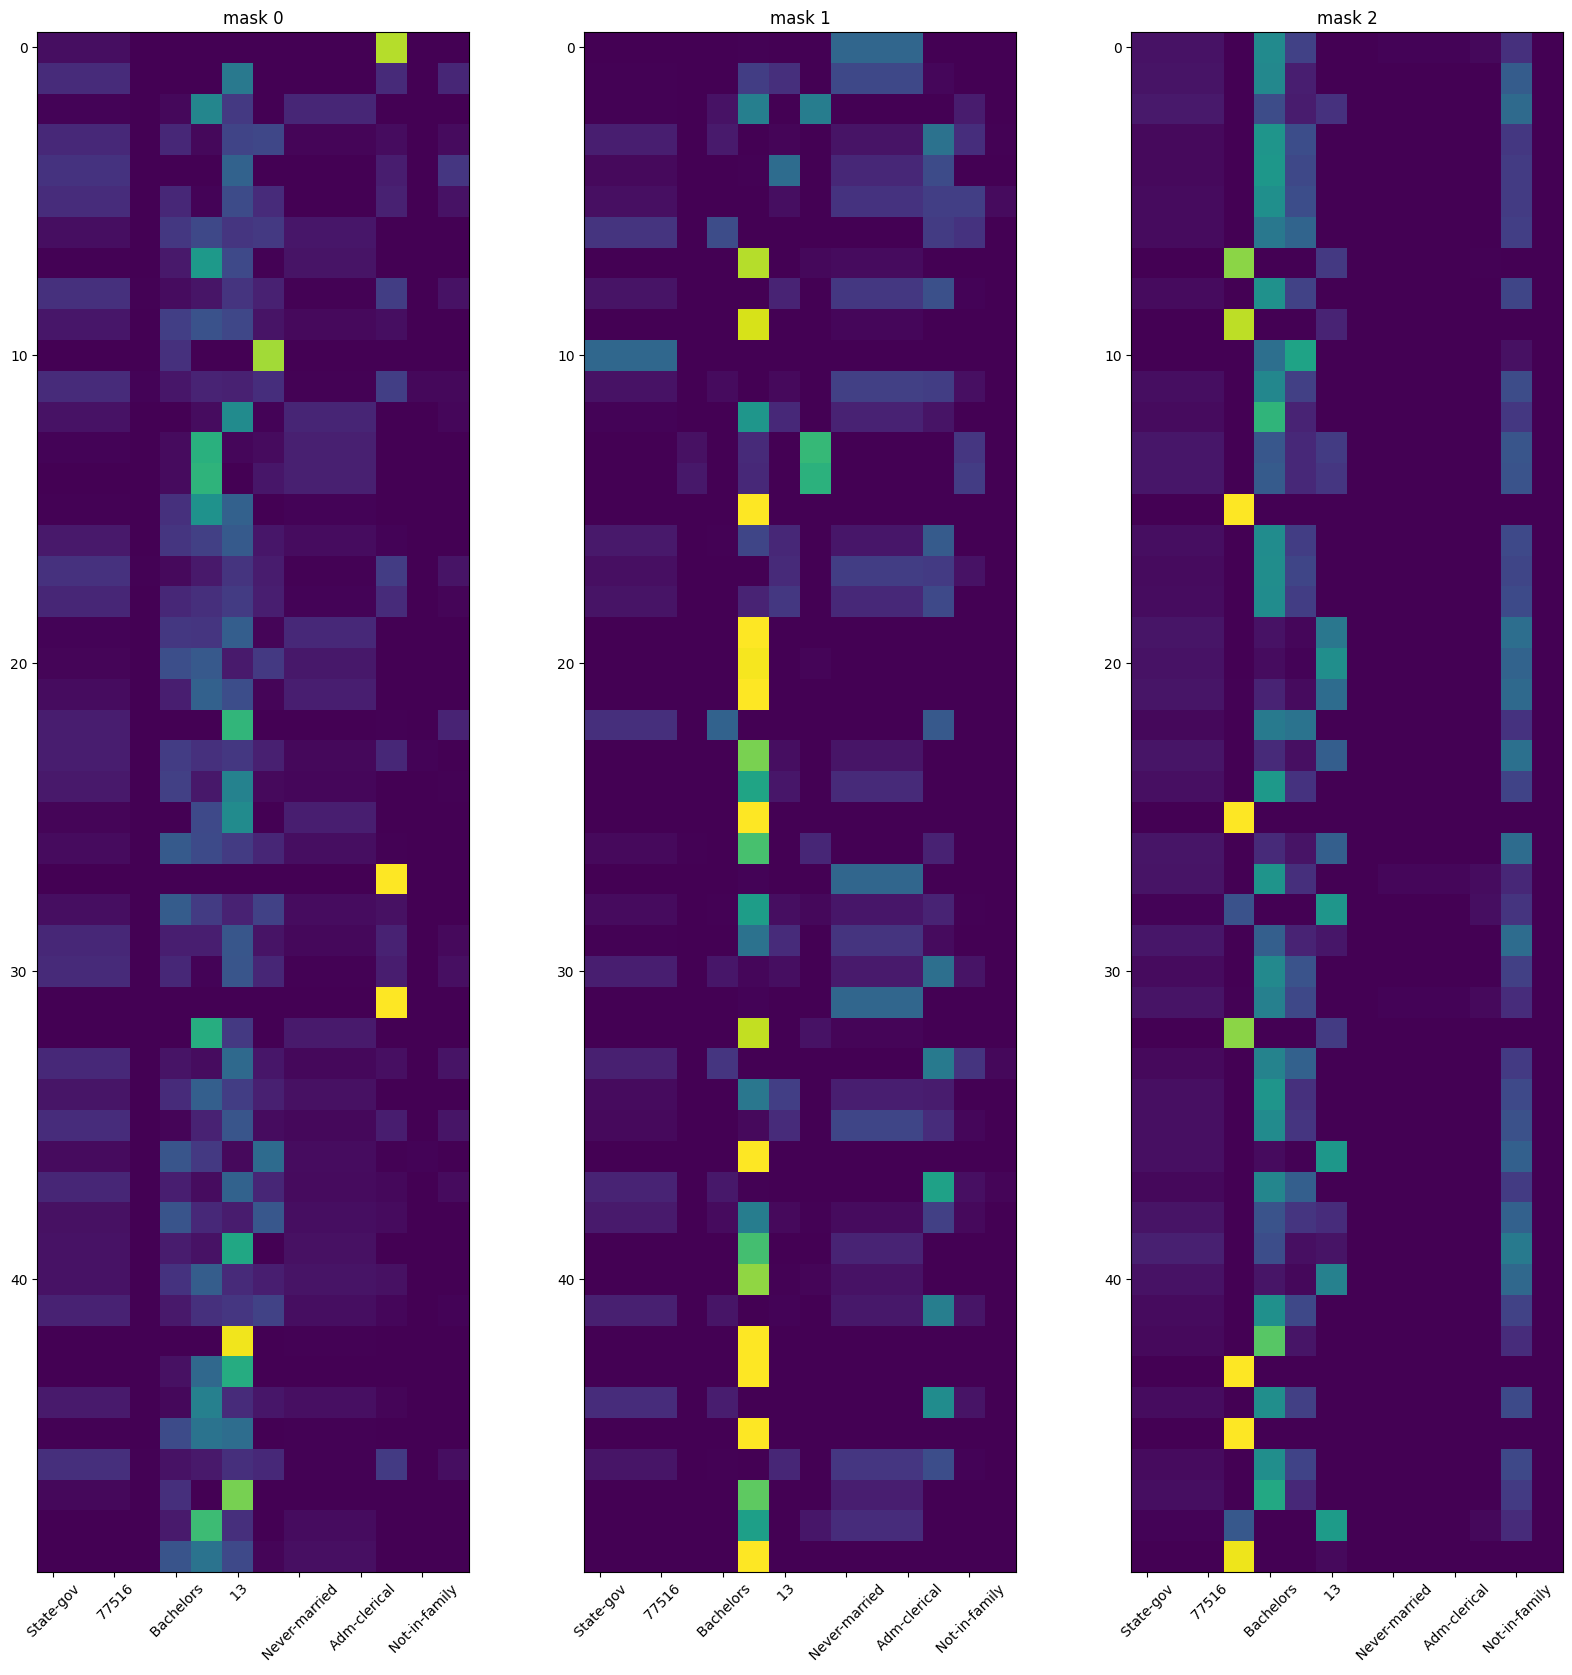

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(20,20))


for i in range(3):
    axs[i].imshow(masks[i][:50])
    axs[i].set_title(f"mask {i}")
    axs[i].set_xticklabels(labels = features, rotation=45)

# XGB

In [36]:
y_train = (y_train == 'wealthy')*1
y_valid = (y_valid == 'wealthy')*1
y_test = (y_test == 'wealthy')*1

In [37]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(max_depth=8,
    learning_rate=0.1,
    n_estimators=1000,
    verbosity=0,
    silent=None,
    objective='binary:logistic',
    booster='gbtree',
    n_jobs=-1,
    nthread=None,
    gamma=0,
    min_child_weight=1,
    max_delta_step=0,
    subsample=0.7,
    colsample_bytree=1,
    colsample_bylevel=1,
    colsample_bynode=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    base_score=0.5,
    random_state=0,
    seed=None,)

clf_xgb.fit(X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=10)

[0]	validation_0-logloss:0.63478
[10]	validation_0-logloss:0.37938
[20]	validation_0-logloss:0.31122
[30]	validation_0-logloss:0.28836
[40]	validation_0-logloss:0.27925
[50]	validation_0-logloss:0.27512
[60]	validation_0-logloss:0.27300
[70]	validation_0-logloss:0.27144
[80]	validation_0-logloss:0.27015
[90]	validation_0-logloss:0.27008
[100]	validation_0-logloss:0.27083
[110]	validation_0-logloss:0.27110
[120]	validation_0-logloss:0.27183
[130]	validation_0-logloss:0.27286
[140]	validation_0-logloss:0.27349
[150]	validation_0-logloss:0.27453
[160]	validation_0-logloss:0.27579
[170]	validation_0-logloss:0.27573
[180]	validation_0-logloss:0.27717
[190]	validation_0-logloss:0.27819
[200]	validation_0-logloss:0.27875
[210]	validation_0-logloss:0.27939
[220]	validation_0-logloss:0.27994
[230]	validation_0-logloss:0.28124
[240]	validation_0-logloss:0.28267
[250]	validation_0-logloss:0.28377
[260]	validation_0-logloss:0.28448
[270]	validation_0-logloss:0.28550
[280]	validation_0-logloss:0.28

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=0, max_depth=8,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, nthread=None, num_parallel_tree=None, ...)

In [38]:
preds = np.array(clf_xgb.predict_proba(X_valid))
valid_auc = roc_auc_score(y_score=preds[:,1], y_true=y_valid)
print(valid_auc)

preds = np.array(clf_xgb.predict_proba(X_test))
test_auc = roc_auc_score(y_score=preds[:,1], y_true=y_test)
print(test_auc)

0.9110206014656277
0.9066786588513054


In [39]:
end = time.time()

In [40]:
delta = int(end - start)

In [41]:
print(delta)

787
